# Selección de Variables (Feature Selection)

**Objetivo:** Determinar cuáles materias primas (X, Y, Z) son estadísticamente relevantes
para predecir el precio de cada equipo. Para ello se llevan a cabo los sigueitnes pasos:

1. Correlación de Pearson y Spearman
2. Prueba de causalidad de Granger
3. Regresión Lasso (regularización L1)
4. Factor de Inflación de Varianza (VIF) — multicolinealidad
5. Regresión OLS con p-values (statsmodels)


In [3]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LassoCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from src.data_loader import build_analysis_dataset

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

RESULTS_DIR = '../results/figures'
import os; os.makedirs(RESULTS_DIR, exist_ok=True)

In [4]:
df = build_analysis_dataset()
features = ['Price_X', 'Price_Y', 'Price_Z']
targets = ['Price_Equipo1', 'Price_Equipo2']
print(f"Dataset: {len(df):,} registros")

Dataset: 3,530 registros


## 1. Correlaciones de Pearson y Spearman

In [5]:
results_corr = []
for target in targets:
    for feat in features:
        r_pearson = df[[feat, target]].corr(method='pearson').iloc[0, 1]
        r_spearman = df[[feat, target]].corr(method='spearman').iloc[0, 1]
        results_corr.append({
            'Target': target.replace('Price_', ''),
            'Feature': feat.replace('Price_', ''),
            'Pearson r': round(r_pearson, 4),
            'Spearman r': round(r_spearman, 4),
            'Pearson |r|': round(abs(r_pearson), 4),
        })

corr_df = pd.DataFrame(results_corr)
print(corr_df.to_string(index=False))

 Target Feature  Pearson r  Spearman r  Pearson |r|
Equipo1       X     0.5234      0.6241       0.5234
Equipo1       Y     0.9966      0.9942       0.9966
Equipo1       Z     0.8440      0.8663       0.8440
Equipo2       X     0.5303      0.6037       0.5303
Equipo2       Y     0.9127      0.9271       0.9127
Equipo2       Z     0.9827      0.9797       0.9827


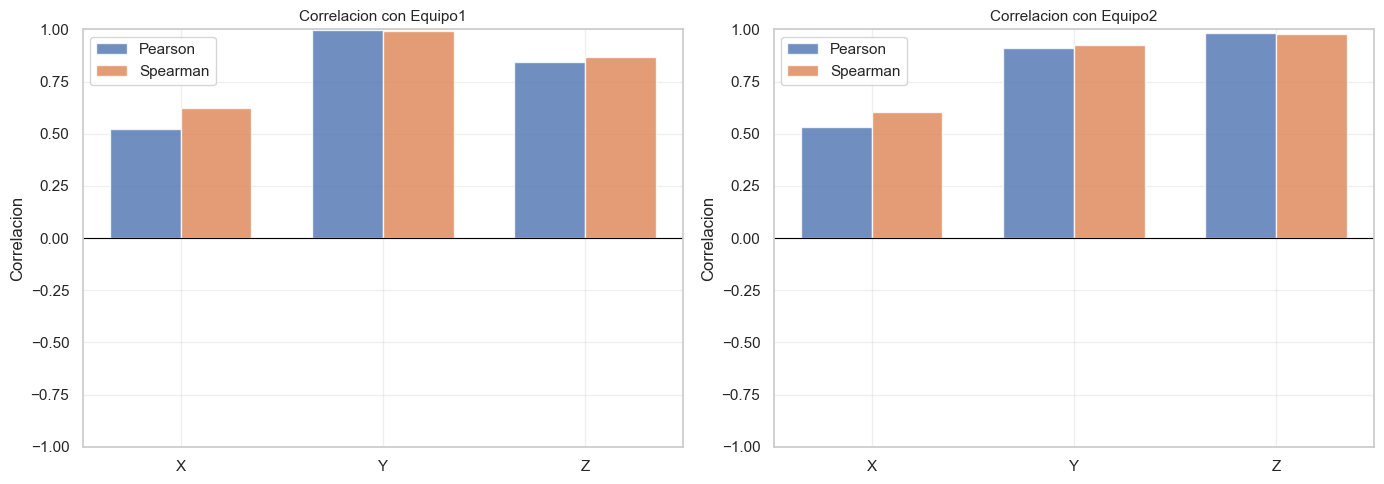

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, targets):
    sub = corr_df[corr_df['Target'] == target.replace('Price_', '')]
    x = np.arange(len(features))
    width = 0.35
    ax.bar(x - width/2, sub['Pearson r'], width, label='Pearson', alpha=0.8)
    ax.bar(x + width/2, sub['Spearman r'], width, label='Spearman', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['X', 'Y', 'Z'])
    ax.set_ylabel('Correlacion')
    ax.set_title(f'Correlacion con {target.replace("Price_","")}', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/06_correlaciones_barras.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Prueba de estacionariedad (ADF) Para el calculo de Granger

In [7]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    is_stationary = p_value < 0.05
    print(f"{name:20s}: p-value={p_value:.4f} | {'ESTACIONARIA' if is_stationary else 'NO estacionaria (requiere diferenciacion)'}")
    return is_stationary

print("=== Prueba Dickey-Fuller Aumentada (ADF) — H0: tiene raiz unitaria ===")
stationary = {}
for col in features + targets:
    stationary[col] = adf_test(df[col], col)

=== Prueba Dickey-Fuller Aumentada (ADF) — H0: tiene raiz unitaria ===
Price_X             : p-value=0.4284 | NO estacionaria (requiere diferenciacion)
Price_Y             : p-value=0.1083 | NO estacionaria (requiere diferenciacion)
Price_Z             : p-value=0.2052 | NO estacionaria (requiere diferenciacion)
Price_Equipo1       : p-value=0.1445 | NO estacionaria (requiere diferenciacion)
Price_Equipo2       : p-value=0.3290 | NO estacionaria (requiere diferenciacion)


In [8]:
# Si las series no son estacionarias, trabajar con primeras diferencias para Granger
df_diff = df[features + targets].diff().dropna()

print("\n=== Prueba ADF sobre primeras diferencias ===")
for col in features + targets:
    adf_test(df_diff[col], f'd({col})')


=== Prueba ADF sobre primeras diferencias ===
d(Price_X)          : p-value=0.0000 | ESTACIONARIA
d(Price_Y)          : p-value=0.0000 | ESTACIONARIA
d(Price_Z)          : p-value=0.0000 | ESTACIONARIA
d(Price_Equipo1)    : p-value=0.0000 | ESTACIONARIA
d(Price_Equipo2)    : p-value=0.0000 | ESTACIONARIA


## 2.1 Visualizacion: serie original vs diferenciada + ACF/PACF

**ACF (Autocorrelation Function):** mide la correlacion de la serie con su propio pasado.
- Serie no estacionaria: el ACF decae *muy lento* (la serie recuerda lejos su pasado)
- Serie estacionaria: el ACF cae rapido a cero (memoria corta)

**PACF (Partial ACF):** correlacion directa con cada lag, eliminando el efecto de los intermedios.
Util para elegir el orden AR del modelo ARIMA en el notebook 03.

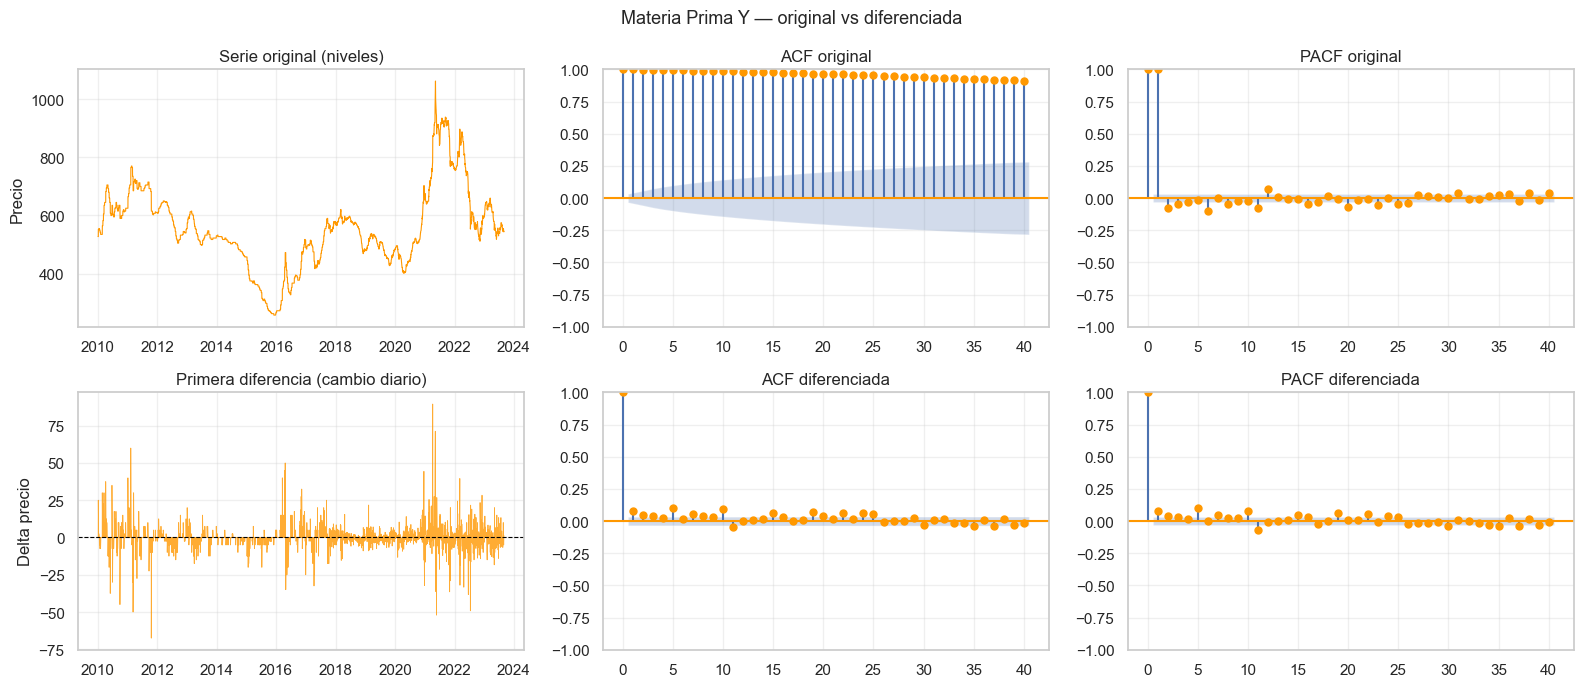

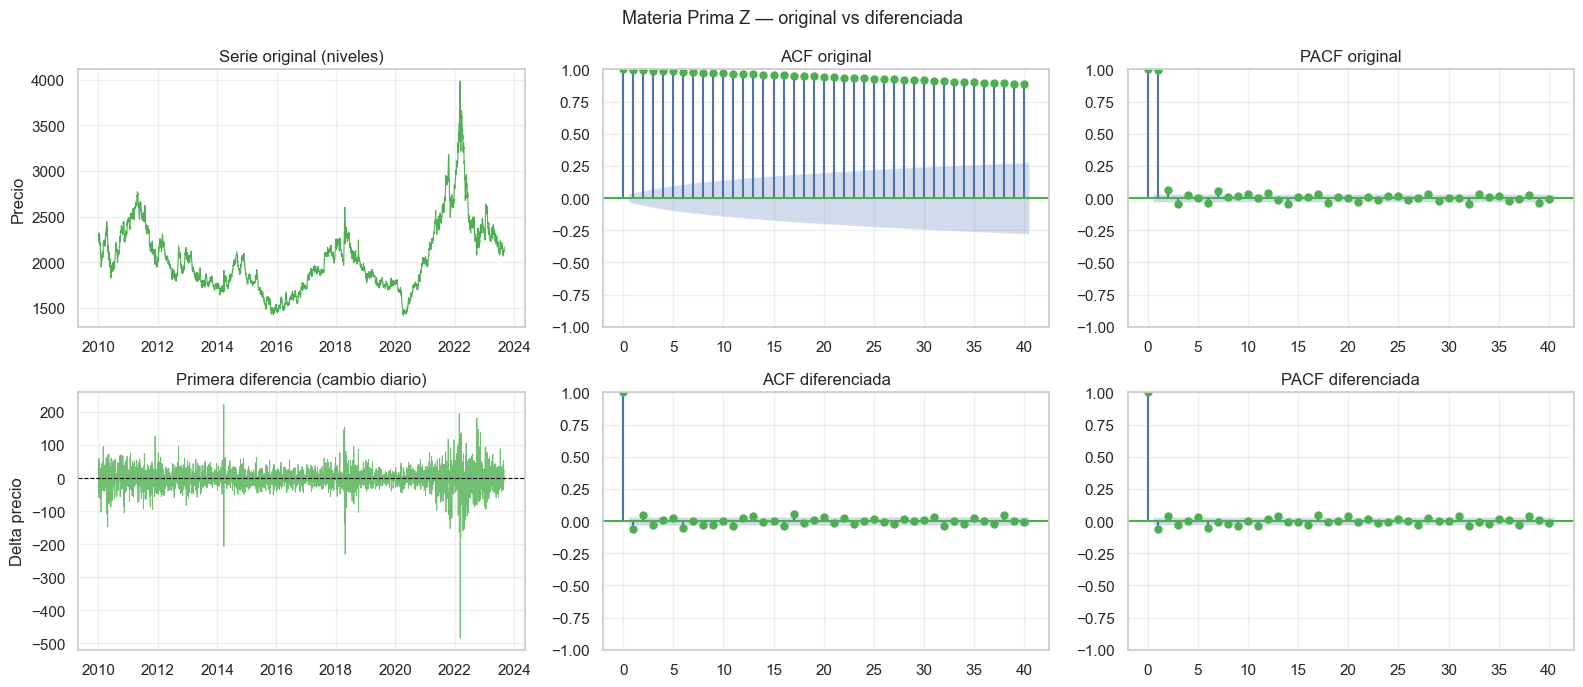

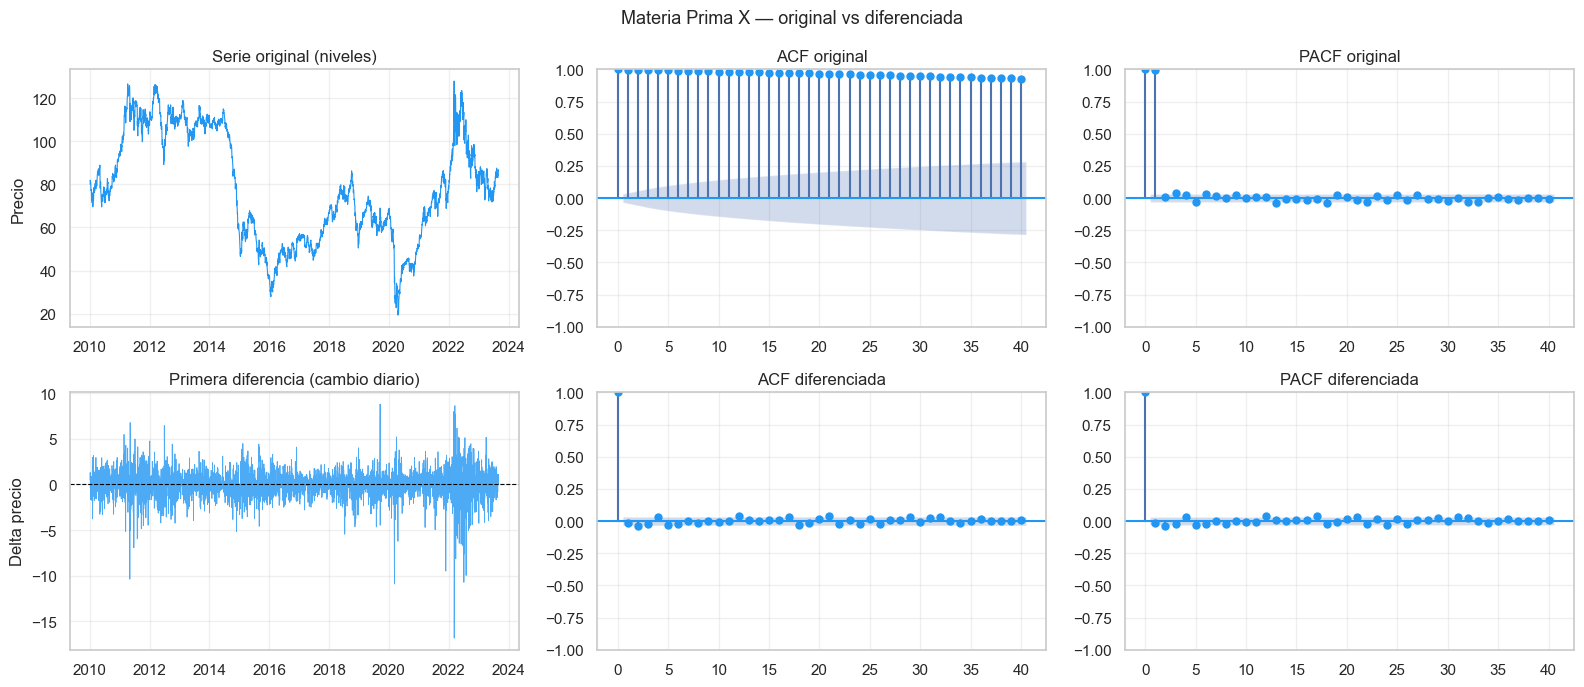

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

vars_to_plot = ["Price_Y", "Price_Z", "Price_X"]
labels      = ["Y", "Z", "X"]
colors      = ["#FF9800", "#4CAF50", "#2196F3"]
LAGS        = 40

for col, label, color in zip(vars_to_plot, labels, colors):
    serie      = df[col].dropna()
    serie_diff = serie.diff().dropna()

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    fig.suptitle(f"Materia Prima {label} — original vs diferenciada", fontsize=13)

    # --- Fila superior: serie original ---
    axes[0, 0].plot(df["Date"], serie, color=color, linewidth=0.8)
    axes[0, 0].set_title("Serie original (niveles)")
    axes[0, 0].set_ylabel("Precio")
    axes[0, 0].grid(True, alpha=0.3)

    plot_acf(serie,  lags=LAGS, ax=axes[0, 1], color=color,
             title="ACF original")
    plot_pacf(serie, lags=LAGS, ax=axes[0, 2], color=color,
              title="PACF original", method="ywm")

    # --- Fila inferior: primera diferencia ---
    axes[1, 0].plot(df["Date"].iloc[1:], serie_diff, color=color,
                    linewidth=0.6, alpha=0.8)
    axes[1, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1, 0].set_title("Primera diferencia (cambio diario)")
    axes[1, 0].set_ylabel("Delta precio")
    axes[1, 0].grid(True, alpha=0.3)

    plot_acf(serie_diff,  lags=LAGS, ax=axes[1, 1], color=color,
             title="ACF diferenciada")
    plot_pacf(serie_diff, lags=LAGS, ax=axes[1, 2], color=color,
              title="PACF diferenciada", method="ywm")

    # Zona de confianza visual en los ACF/PACF
    for ax in axes.flat:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/acf_pacf_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()




ACF original decae lento = serie NO estacionaria (confirma ADF)
ACF diferencia cae rapido a 0 = serie estacionaria


## 3. Prueba de Causalidad de Granger

H0: la materia prima X **no** causa (en el sentido de Granger) el precio del equipo.
Si p-value < 0.05 → rechazamos H0 → X ayuda a predecir el precio del equipo i.

In [10]:
MAX_LAG = 10  # hasta 10 días hábiles de rezago (~2 semanas)

granger_results = []

for target in targets:
    for feat in features:
        data_gc = df_diff[[target, feat]].dropna()
        try:
            test = grangercausalitytests(data_gc, maxlag=MAX_LAG, verbose=False)
            # Tomar el p-value mínimo entre todos los lags (evidencia más fuerte)
            min_pval = min(
                test[lag][0]['ssr_chi2test'][1]  # chi2 test p-value
                for lag in range(1, MAX_LAG + 1)
            )
            best_lag = min(
                range(1, MAX_LAG + 1),
                key=lambda lag: test[lag][0]['ssr_chi2test'][1]
            )
            granger_results.append({
                'Target': target.replace('Price_', ''),
                'Feature': feat.replace('Price_', ''),
                'Min p-value': round(min_pval, 6),
                'Mejor lag (dias)': best_lag,
                'Significativa (p<0.05)': min_pval < 0.05
            })
        except Exception as e:
            print(f"Error en {feat} -> {target}: {e}")

granger_df = pd.DataFrame(granger_results)
print(granger_df.to_string(index=False))

 Target Feature  Min p-value  Mejor lag (dias)  Significativa (p<0.05)
Equipo1       X     0.000122                 4                    True
Equipo1       Y     0.000000                10                    True
Equipo1       Z     0.000000                10                    True
Equipo2       X     0.000000                 4                    True
Equipo2       Y     0.000000                 6                    True
Equipo2       Z     0.000000                10                    True


## 4. Factor de Inflación de Varianza (VIF) — Multicolinealidad

In [12]:
X_vif = df[features].copy()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['Variable'] != 'const'].reset_index(drop=True)


print(vif_data.round(2).to_string(index=False))

Variable  VIF
 Price_X 1.34
 Price_Y 3.61
 Price_Z 3.54


## 5. Regresión Lasso — Selección automática de features

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

lasso_results = {}

for target in targets:
    y = df[target].values
    lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
    lasso.fit(X_scaled, y)
    
    coefs = pd.Series(lasso.coef_, index=['X', 'Y', 'Z'])
    lasso_results[target] = coefs
    
    print(f"\n{target} — alpha optimo: {lasso.alpha_:.4f}")
    print(f"Variables seleccionadas (coef != 0): {list(coefs[coefs != 0].index)}")
    print(coefs.round(4))


Price_Equipo1 — alpha optimo: 0.1133
Variables seleccionadas (coef != 0): ['X', 'Y']
X      4.9260
Y    110.7456
Z      0.0000
dtype: float64

Price_Equipo2 — alpha optimo: 0.1671
Variables seleccionadas (coef != 0): ['X', 'Y', 'Z']
X      8.2817
Y     46.5293
Z    123.6862
dtype: float64


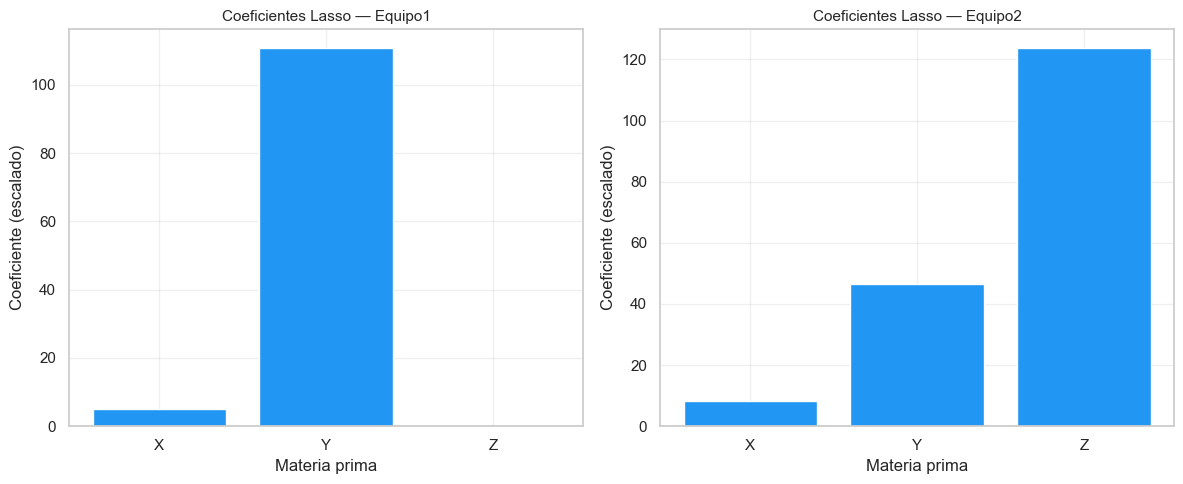

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (target, coefs) in zip(axes, lasso_results.items()):
    colors = ['#2196F3' if c > 0 else '#F44336' if c < 0 else '#9E9E9E' for c in coefs]
    ax.bar(coefs.index, coefs.values, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Coeficientes Lasso — {target.replace("Price_","")}', fontsize=11)
    ax.set_ylabel('Coeficiente (escalado)')
    ax.set_xlabel('Materia prima')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/07_lasso_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Regresión OLS con p-values (statsmodels)

In [15]:
ols_results = {}

for target in targets:
    X_ols = sm.add_constant(df[features])
    y_ols = df[target]
    model = sm.OLS(y_ols, X_ols).fit()
    ols_results[target] = model
    
    print(f"\n{'='*60}")
    print(f"OLS — {target}")
    print(f"R²: {model.rsquared:.4f} | R² ajustado: {model.rsquared_adj:.4f}")
    print(f"AIC: {model.aic:.2f} | BIC: {model.bic:.2f}")
    
    print(f"Durbin-Watson: {durbin_watson(model.resid):.4f}")
    print("\nCoeficientes:")
    summary_df = pd.DataFrame({
        'Coef': model.params,
        'Std Err': model.bse,
        'p-value': model.pvalues,
        'Significativa': model.pvalues < 0.05
    }).round(4)
    print(summary_df)


OLS — Price_Equipo1
R²: 0.9947 | R² ajustado: 0.9947
AIC: 24934.26 | BIC: 24958.94
Durbin-Watson: 1.9639

Coeficientes:
           Coef  Std Err  p-value  Significativa
const   -0.0831   0.7958   0.9168          False
Price_X  0.1987   0.0064   0.0000           True
Price_Y  0.8003   0.0019   0.0000           True
Price_Z  0.0000   0.0007   0.9989          False

OLS — Price_Equipo2
R²: 0.9915 | R² ajustado: 0.9915
AIC: 29447.66 | BIC: 29472.34
Durbin-Watson: 2.0402

Coeficientes:
           Coef  Std Err  p-value  Significativa
const    1.2278   1.5081   0.4156          False
Price_X  0.3333   0.0121   0.0000           True
Price_Y  0.3362   0.0036   0.0000           True
Price_Z  0.3318   0.0013   0.0000           True


## 7. Resumen consolidado — Variables seleccionadas

In [17]:
print("\n" + "="*70)
print("RESUMEN DE SELECCION DE VARIABLES")
print("="*70)

for target in targets:
    model = ols_results[target]
    lasso_coefs = lasso_results[target]
    
    print(f"\n{target.replace('Price_','')}:")
    for feat in features:
        feat_name = feat.replace('Price_', '')
        p_val = model.pvalues.get(feat, 1.0)
        lasso_coef = lasso_coefs.get(feat_name, 0)
        granger_row = granger_df[(granger_df['Target'] == target.replace('Price_','')) & 
                                  (granger_df['Feature'] == feat_name)]
        granger_sig = granger_row['Significativa (p<0.05)'].values[0] if len(granger_row) > 0 else False
        
        ols_sig = '✓' if p_val < 0.05 else 'x'
        lasso_sig = '✓' if lasso_coef != 0 else 'x'
        granger_sym = '✓' if granger_sig else 'x'
        
        print(f"  {feat_name}: OLS={ols_sig} (p={p_val:.4f}) | Lasso={lasso_sig} (coef={lasso_coef:.3f}) | Granger={granger_sym}")

print("Conclusion: variables a usar en el modelo predictivo")
print()
print("(Las que son significativas en al menos 2 de 3 metodos)")


RESUMEN DE SELECCION DE VARIABLES

Equipo1:
  X: OLS=✓ (p=0.0000) | Lasso=✓ (coef=4.926) | Granger=✓
  Y: OLS=✓ (p=0.0000) | Lasso=✓ (coef=110.746) | Granger=✓
  Z: OLS=x (p=0.9989) | Lasso=x (coef=0.000) | Granger=✓

Equipo2:
  X: OLS=✓ (p=0.0000) | Lasso=✓ (coef=8.282) | Granger=✓
  Y: OLS=✓ (p=0.0000) | Lasso=✓ (coef=46.529) | Granger=✓
  Z: OLS=✓ (p=0.0000) | Lasso=✓ (coef=123.686) | Granger=✓
Conclusion: variables a usar en el modelo predictivo

(Las que son significativas en al menos 2 de 3 metodos)


## 8. Exportar selección final para el notebook de modelado

In [18]:
import json

selected_features = {
    'Price_Equipo1': [],
    'Price_Equipo2': [],
}

for target in targets:
    model = ols_results[target]
    lasso_coefs = lasso_results[target]
    
    for feat in features:
        feat_name = feat.replace('Price_', '')
        ols_sig = model.pvalues.get(feat, 1.0) < 0.05
        lasso_sig = lasso_coefs.get(feat_name, 0) != 0
        granger_row = granger_df[(granger_df['Target'] == target.replace('Price_','')) & 
                                  (granger_df['Feature'] == feat_name)]
        granger_sig = granger_row['Significativa (p<0.05)'].values[0] if len(granger_row) > 0 else False
        
        # Seleccionar si es significativa en al menos 2 de 3 métodos
        votes = sum([ols_sig, lasso_sig, granger_sig])
        if votes >= 2:
            selected_features[target].append(feat)

os.makedirs('../results', exist_ok=True)
with open('../results/selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)

print("Variables seleccionadas exportadas a results/selected_features.json")
print(json.dumps(selected_features, indent=2))

Variables seleccionadas exportadas a results/selected_features.json
{
  "Price_Equipo1": [
    "Price_X",
    "Price_Y"
  ],
  "Price_Equipo2": [
    "Price_X",
    "Price_Y",
    "Price_Z"
  ]
}


### Conclusiones

* Todas las series son I(1), las correlaciones altas en niveles tenían riesgo de ser espurias, pero el DW≈2 en OLS sugiere relaciones genuinas
* Granger confirmó causalidad real para todas las combinaciones. Las materias primas sí predicen los equipos más allá de la tendencia común
* VIF < 5 — multicolinealidad manejable, las tres variables pueden coexistir en el modelo
* Lasso y OLS coinciden perfectamente — alta confianza en la selección
* Limitación reconocida: Lasso en niveles no es el método ideal para series de tiempo; Granger lo complementa y valida los mismos resultados
